# Variational Inference using VAEs and Normalizing Flows

## Setting the Scene

In this assignment, we implement a vanilla VAE from scratch and train it on grayscale images of the MNIST handwritten digits dataset.
Then, we train the same model but use a Normalizing Flow as variational distribution to approximate the true posterior.

For the (vanilla) VAE:

- Suggest one final version that uses dense-layers only *or* convolution/de-convolution.
- Assume a standard normal prior belief.
- Use a diagonal Gaussion as variational distribution.
- As reconstruction loss, choose between MSE and BCE.
- If necessary, implement it as a $\beta$-VAE that allows you to put an (adaptive) weight on the KL-divergence.

Much like the previous assignment, you shall fill out the blanks, answer the questions, and evaluate and compare your trained models.
However, we will not be implementing Normalizing Flows, due to the complexity of bijectors, conditioners, and other required coupling blocks.
Instead, you shall use a library/framework.

Suggested are these 2:

- PyTorch: Use the `normflows` package: <https://github.com/VincentStimper/normalizing-flows> (preferred)
- JAX: Use the `pzflow` package: <https://github.com/jfcrenshaw/pzflow>

It is acceptable to use something else, but make sure you can integrate it nicely into your VAE implementation.
As for the NF model itself:

- Use a diagonal Gaussian base distribution 
- Try to keep the model relatively shallow (less than ca. ten blocks)
- Attempt to use as few as possible parameters in the conditioners


# <u>Make a Choice!</u>

- Choose between a dense or convolutional architecture for your encoder/decoder (don't mix).
- Use the same architecture for encoder/decoder in the vanilla and NF-backed VAE to keep it fair.
- Keep the KL-$\beta$ in the range $[2,5]$ -- but don't change between models, chose one for both.

## If you choose Dense

Limits:
- Bottleneck = 3
- Total params encoder + decoder = 400k

## If you choose Convolutional

Limits:
- Bottleneck = 5
- Total params encoder + decoder = 200k

# Part 1: Implement your own VAE

## Recap: Variational Bayes

In our first lecture and assignment, we took a Bayesian variational approach to **quantify uncertainty** in our model's parameters.
Let's call this **Scenario A**.

In **A**,
- we have a polynomial with a handful of parameters.
- Our prior belief over these parameters $p(\mathbf{w})=\mathcal{N}(0,I)$.
- The true posterior, $p(\mathbf{w}\vert\mathbf{X},\mathbf{y})$, is approximated using a mean-field variational distribution. Our choise was a diagonal Gaussian: $q_{\phi}(\mathbf{w})=\mathcal{N}(\mu_{\phi},\Sigma_{\phi})$.
- The ELBO was: $\text{ELBO}=\mathbb{E}_{q_{\phi}(\mathbf{w})}\left[\log{(p(\mathbf{y}|\mathbf{X},\mathbf{w}))}\right]-D_{\text{KL}}\left(q_{\phi}(\mathbf{w})\|p(\mathbf{w})\right)$.
- The Monte Carlo approximation of the ELBO is: $\text{ELBO}(\phi)\approx\frac{1}{S}\sum_{s=1}^{S}\,\underbrace{\left[\sum_{i=1}^{N}\,\log{(p(y_i|x_i,w^{(s)}))}\right]}_{\text{log-sum of i.i.d. observations}}-\underbrace{\left[\log{\left(q_{\mu,\sigma}\left(w^{(s)}\right)\right)}-\log{\left(p\left(w^{(s)}\right)\right)}\right]}_{\text{MC-approx. of KL-divergence}}$.


So, in order to introduce variation, we insert randomness into our model using the reparameterization trick.
Since we optimize the current $\mu,\sigma$ of our variational distribution, it needs to be differentiable w.r.t. those parameters.
Recall that $w=\mu+\sigma\cdot\epsilon$.
So, in order to average the effect of many different $w^{(s)}\in W$, we compute the mean of our model's predictions using these varying parameters.
Then, we maximize the average ELBO.

## Differences in a Variational Autoencoder

Now, in a vanilla variational autoencoder (VAE), we **quantify uncertainty in the latent variables, per individial observation**.
Here, we will make use of so-called **amortized inference**.

A VAE has these components:
- An **Encoder** Network.
    * Takes the input data and predicts, for **each** observation $x_i\in\mathbf{X}$, the parameters of our approximate posterior $q_{\phi}(\mathbf{Z}|\mathbf{X})=\mathcal{N}(\mathbf{Z}, \mathbf{\mu}_{\phi}(\mathbf{X}),\Sigma_{\phi}(\mathbf{X}))$.
    * The conditional prediction (per observation) of the variational parameters is called amortized inference.
    * If our latent dimension is 20, for example, then we would need to predict 20 means and 20 variances, per observation.
    * The reparameterization trick lies in constructing $z=\mu+\sigma\cdot\epsilon$ for an epsilon drawn from a standard normal. Then, it is this $z$ that gets decoded.
- A set of latent variables (denoted $\mathbf{Z}$). Usually the dimensionality of $\mathbf{Z}$ is lower than that of the input, $X$.
- A **Decoder** Network.
    * Given $\mathbf{Z}$, learns to predict a reconstructed $\mathbf{X}'\approx\mathbf{X}$.

<pre>
Input X --> Encoder Network (phi)  --> Latent variables Z ~ q_{phi}(Z|X) -->
    Decoder Network (theta)  -->  Reconstructed X (X').
</pre>

Notice how our **prior** belief relates now to hoe each $z_i$ is distributed.
Again, here we will assume $p(\mathbf{Z})\sim\mathcal{N}(0,I)$.
During training, we will minimize again the Kullback-Leibler divergence between this prior belief and our mean-field approximation:

$$
\begin{align}
    D_{\text{KL}}\left(q_{\phi}(z|x)\,\|\,p(z)\right)
\end{align}
$$

for **each** observation $x$.
If we now add a reconstruction term, it will constitute the ELBO loss.
Since each observation constitutes itw own Gaussian in latent space, $q_{\phi}(z|x)$ differs for each x.
Therefore, only the **aggregate** distribution $q_{\phi}(z)$ matches the prior.
The encoder network naturally shares (has the same set of) parameters across all observations, making it generalize to the dataset.

## Implementation

The following is a skeleton for a PyTorch-based implementation.

You may or may not follow this skeleton, it is just a suggestion.

Choose one architecture that works best for you (dense <u>**or**</u> convolutional).

In [1]:
import torch
from torch import nn, Tensor


class MyVAE(nn.Module):
    """
    A vanilla VAE with standard normal prior belief and normal independent variational
    distribution. Has a configurable latent size.
    """

    def __init__(self, dim: int, dim_z: int, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.dim = dim
        self.dim_z = dim_z
        hidden_size = 60

        # Encoder: Convolutional layers
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(int(dim / 4)**2 * 32, hidden_size),
            nn.ReLU()
        )

        # Output projection to mu and log_var
        self.fc_mu = nn.Linear(hidden_size, dim_z)
        self.fc_log_var = nn.Linear(hidden_size, dim_z)

        # Decoder: From latent space to reconstruction
        self.decoder_input = nn.Linear(dim_z, hidden_size)

        self.decoder = nn.Sequential(
            nn.Linear(hidden_size, int(dim / 4)**2 * 32),
            nn.ReLU(),
            nn.Unflatten(1, (32, int(dim/4), int(dim/4))),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1 if dim % 4 == 0 else 0),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

        # Count parameters to verify limits
        param_count = sum([p.numel() for p in self.parameters()])
        print(f"Total parameters: {param_count:,}")


    def encode(self, x: Tensor) -> tuple[Tensor, Tensor]:
        """Encodes the input and returns the mus and log variances."""
        h = self.encoder(x)
        mu = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var


    def decode(self, z: Tensor) -> Tensor:
        """Decode latent samples back to image space."""
        h = self.decoder_input(z)
        h = self.decoder(h)
        return h


    def reparameterize(self, mu: Tensor, log_var: Tensor) -> Tensor:
        """Apply the reparameterization trick."""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std


    def forward(self, x: Tensor) -> tuple[Tensor, Tensor]:
        """
        Takes the original input, encodes it, applies the R-trick,
        reconstructs the inputs, and calculates the KL-divergence.
        Returns the reconstruction and the divergence.
        """
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        recon_x = self.decode(z)

        # Calculate KL divergence
        kl_div = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1)
        kl_div = kl_div.mean()

        return recon_x, kl_div


    def sample(self, n: int) -> Tensor:
        """Sample from the trained model using the unconditional prior."""
        with torch.no_grad():
            z = torch.randn(n, self.dim_z)
            samples = self.decode(z)
        return samples


    def interpolate(self, z1: Tensor, z2: Tensor, steps: int = 8) -> Tensor:
        """Interpolate between two latent codes."""

        size = z1.shape[1:]

        with torch.no_grad():
            # Create interpolation weights
            alphas = torch.linspace(0, 1, steps)

            # Interpolate latents
            interpolated_zs = []
            for alpha in alphas:
                z_interp = (1 - alpha) * z1 + alpha * z2
                interpolated_zs.append(z_interp)

            # Stack, encode and decode
            z_stack = torch.cat(interpolated_zs)
            z_mu, _ = self.encode(z_stack)
            samples = self.decode(z_mu)

            # Reshape to separate steps and batch dimensions
            samples = samples.view(steps, *size)

            return samples

# Training

We will train on grayscale MNIST handwritten digits.
The goal is to train either architecture and then to compare the results.

## Download and Prepare the Data

In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

batch_size = 256

transform = transforms.Compose([ transforms.ToTensor() ])

# Download and load MNIST training set
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, drop_last=True, shuffle=True)

# Load MNIST test set
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, drop_last=True, shuffle=False)

In [3]:
train_dataset.data.shape, test_dataset.data.shape

(torch.Size([60000, 28, 28]), torch.Size([10000, 28, 28]))

## Using ELBO

Recall that the ELBO is essentially the expectation of the log-likelihood of the data under our currently parameterized model minus the KL-divergence of the variational distribution and the prior belief.

Recall that the (log-)likelihood function does not have to be a proper probability density.
Instead, it should yield values that allow relative comparisons on how well the certain parameters represent our data.
Here, $f_{\theta}$ represents our decoder that reconstructs the inputs, i.e., $f\mapsto X'$.

$$
\begin{align}
    \text{ELBO}(\theta,\phi;x)=\mathbb{E}_{q_{\phi}(z|x)}\left[-\text{reconstruction loss}\left(x,f_{\theta}(z)\right)\right]-D_{\text{KL}}\left(q_{\phi}(z|x)\,\|\,p(z)\right)\nonumber.
\end{align}
$$


In a VAE, we typically have a reconstruction loss like MSE.
We can just plug it into the expectation and use it as our likelihood.
Then, we negate the ELBO to obtain our loss objective $\mathcal{J}$ for minimization:

$$
\begin{align}
    \operatorname{MSE}\left(x,\mu_{\theta}(z)\right)&=\left\|x-\mu_{\theta}(z)\right\|^2,\nonumber
    \\[1em]
    \mathcal{J}(\theta,\phi;x)&=\underbrace{\mathbb{E}_{q_{\phi}(z|x)}\left[\left\|x-\mu_{\theta}(z)\right\|^2\right]}_{\text{expected (mean) reconstr. error}} + D_{\text{KL}}\left(q_{\phi}(z|x)\,\|\,p(z)\right)\nonumber.
\end{align}
$$

## The Vanilla VAE

Let's train this model first.
It is perhaps easiest to use the same training routine for either model (with/without NF).

In [4]:
import numpy as np
from torch import device
from torch.optim import Adam
import matplotlib.pyplot as plt
from tqdm import tqdm


DEVICE = device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)
DIM_Z = 5
LEARNING_RATE = 0.001
NUM_EPOCHS = 20

VAE = MyVAE(dim=train_dataset.data.shape[1], dim_z=DIM_Z).to(device=DEVICE)
optim = Adam(params=VAE.parameters(), lr=LEARNING_RATE)


def reconstruction_loss(recon_x, x):
    """Binary cross entropy loss for reconstruction."""
    # Flatten the images for BCE calculation
    recon_flat = recon_x.view(recon_x.size(0), -1)
    x_flat = x.view(x.size(0), -1)
    return torch.sum(torch.nn.functional.binary_cross_entropy(recon_flat, x_flat, reduction='none'), dim=1).mean()


def train_epoch(model, dataloader, optimizer, epoch):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    total_recon_loss = 0
    total_kl_loss = 0

    progress_bar = tqdm(dataloader, desc=f'Epoch {epoch}')
    for batch_idx, (data, _) in enumerate(progress_bar):
        data = data.to(DEVICE)

        optimizer.zero_grad()

        # Forward pass
        recon_data, kl_div = model(data)

        # Calculate reconstruction loss
        recon_loss = reconstruction_loss(recon_data, data)

        # Total loss (negative ELBO)
        loss = recon_loss + kl_div

        # Backward pass
        loss.backward()
        optimizer.step()

        # Track losses
        total_loss += loss.item()
        total_recon_loss += recon_loss.item()
        total_kl_loss += kl_div.item()

        # Update progress bar
        progress_bar.set_postfix({
            'loss': loss.item(),
            'recon': recon_loss.item(),
            'kl': kl_div.item()
        })

    n_batches = len(dataloader)
    return (total_loss / n_batches,
            total_recon_loss / n_batches,
            total_kl_loss / n_batches)


def evaluate(model, dataloader):
    """Evaluate the model on test/validation set."""
    model.eval()
    total_loss = 0
    total_recon_loss = 0
    total_kl_loss = 0

    with torch.no_grad():
        for data, _ in dataloader:
            data = data.to(DEVICE)

            # Forward pass
            recon_data, kl_div = model(data)
            recon_loss = reconstruction_loss(recon_data, data)

            total_loss += (recon_loss + kl_div).item()
            total_recon_loss += recon_loss.item()
            total_kl_loss += kl_div.item()

    n_batches = len(dataloader)
    return (total_loss / n_batches,
            total_recon_loss / n_batches,
            total_kl_loss / n_batches)


# Training loop
print("Starting training...")
train_losses = []
test_losses = []
train_recon_losses = []
test_recon_losses = []
train_kl_losses = []
test_kl_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    # Train
    train_loss, train_recon, train_kl = train_epoch(VAE, train_loader, optim, epoch)
    train_losses.append(train_loss)
    train_recon_losses.append(train_recon)
    train_kl_losses.append(train_kl)

    # Evaluate
    test_loss, test_recon, test_kl = evaluate(VAE, test_loader)
    test_losses.append(test_loss)
    test_recon_losses.append(test_recon)
    test_kl_losses.append(test_kl)

    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print(f"Train - Loss: {train_loss:.4f}, Recon: {train_recon:.4f}, KL: {train_kl:.4f}")
    print(f"Test  - Loss: {test_loss:.4f}, Recon: {test_recon:.4f}, KL: {test_kl:.4f}")

# Final evaluation
print("\n" + "="*50)
print("Training completed!")
print(f"Final Test Loss: {test_losses[-1]:.4f}")
print(f"Final Test Reconstruction Loss: {test_recon_losses[-1]:.4f}")
print(f"Final Test KL Divergence: {test_kl_losses[-1]:.4f}")

cpu
Total parameters: 200,327
Starting training...


Epoch 1: 100%|██████████| 234/234 [00:05<00:00, 45.08it/s, loss=184, recon=178, kl=6.27]



Epoch 1/20
Train - Loss: 228.7245, Recon: 222.9655, KL: 5.7590
Test  - Loss: 184.6401, Recon: 178.4146, KL: 6.2255


Epoch 2: 100%|██████████| 234/234 [00:05<00:00, 44.43it/s, loss=144, recon=134, kl=9.56]



Epoch 2/20
Train - Loss: 164.4158, Recon: 156.2310, KL: 8.1848
Test  - Loss: 145.2970, Recon: 135.5219, KL: 9.7751


...


Epoch 18/20
Train - Loss: 125.1534, Recon: 113.5656, KL: 11.5879
Test  - Loss: 124.4831, Recon: 112.8327, KL: 11.6504


Epoch 19: 100%|██████████| 234/234 [00:04<00:00, 46.92it/s, loss=127, recon=115, kl=11.7]



Epoch 19/20
Train - Loss: 124.8846, Recon: 113.2708, KL: 11.6138
Test  - Loss: 124.7739, Recon: 113.0732, KL: 11.7007


Epoch 20: 100%|██████████| 234/234 [00:05<00:00, 46.78it/s, loss=128, recon=117, kl=11.5]



Epoch 20/20
Train - Loss: 124.6710, Recon: 113.0287, KL: 11.6423
Test  - Loss: 124.3221, Recon: 112.7949, KL: 11.5272

Training completed!
Final Test Loss: 124.3221
Final Test Reconstruction Loss: 112.7949
Final Test KL Divergence: 11.5272


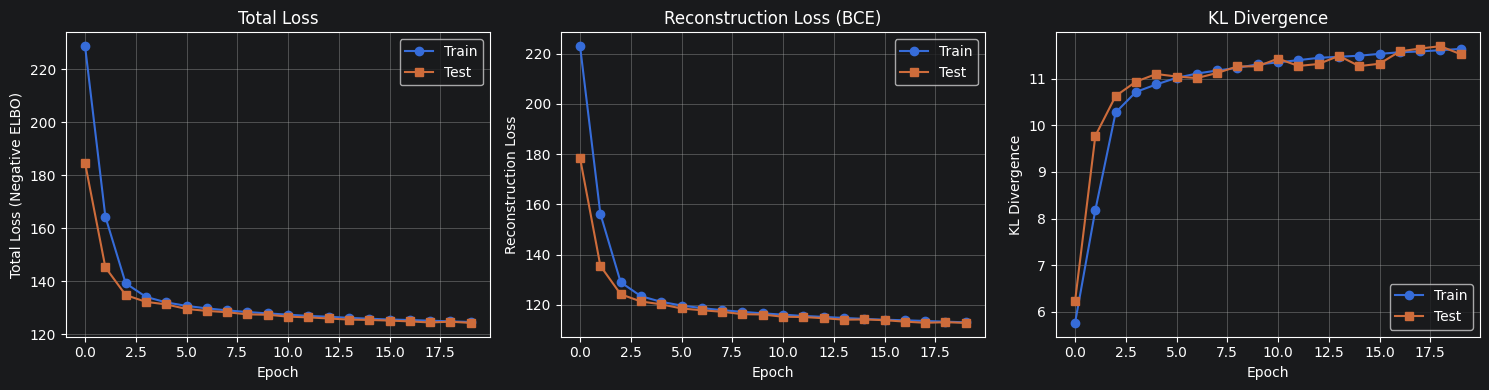

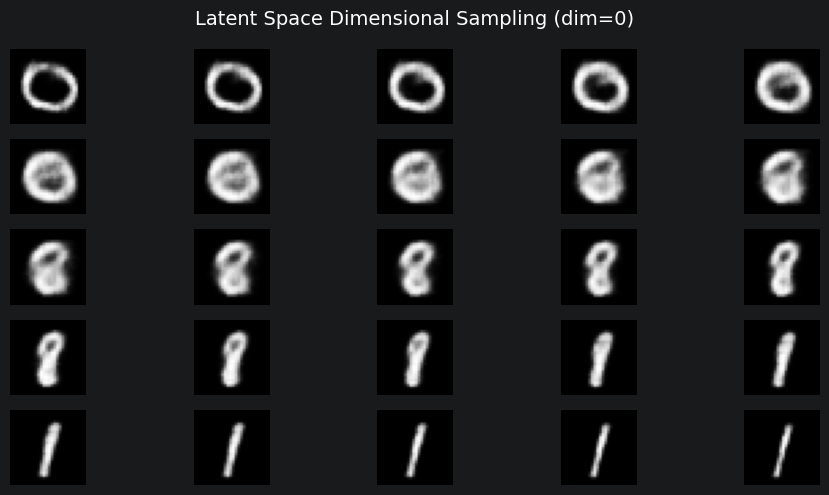

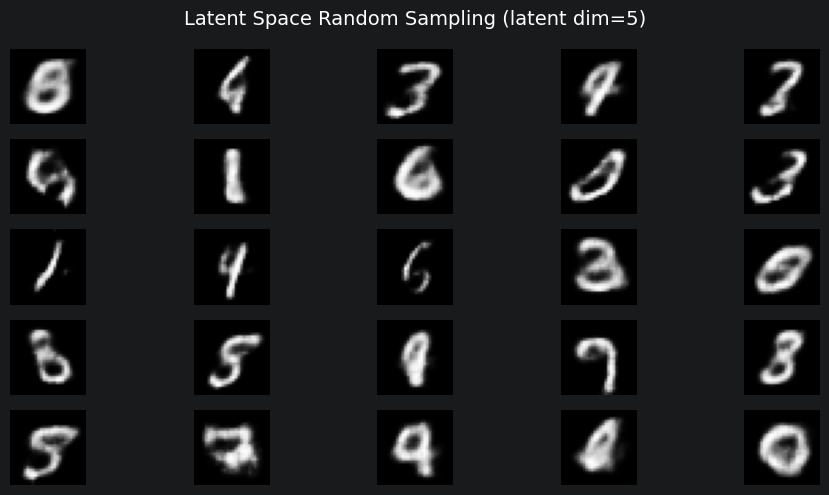

100%|██████████| 39/39 [00:00<00:00, 78.70it/s]


Latent space shape: (9984, 5)
Performing t-SNE dimensionality reduction from 5D to 2D...


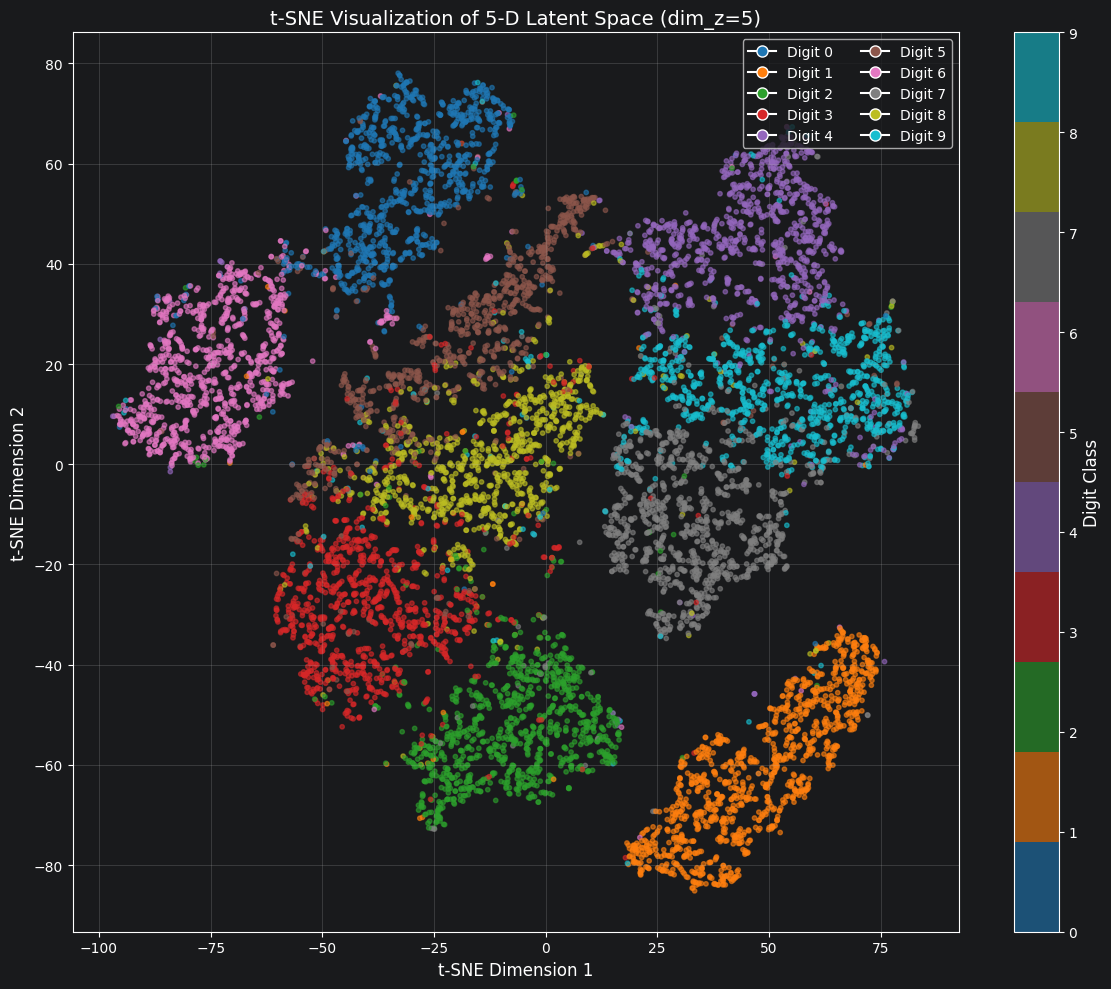

In [5]:
from sklearn.manifold import TSNE


def visualize_latent_space(model, dataloader, perplexity=30, n_samples=None):
    """Visualize latent space using t-SNE dimensionality reduction."""
    model.eval()

    all_zs = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, (data, labels) in enumerate(tqdm(dataloader)):
            mu, _ = model.encode(data)  # Get latent means
            all_zs.append(mu.cpu().numpy())
            all_labels.append(labels.numpy())

            # Limit number of samples if specified
            if n_samples and len(all_zs) * data.size(0) >= n_samples:
                break

    # Concatenate all batches
    zs = np.concatenate(all_zs, axis=0)  # Shape: (N, dim_z)
    labels = np.concatenate(all_labels, axis=0)

    # Limit to n_samples if specified
    if n_samples and len(zs) > n_samples:
        indices = np.random.choice(len(zs), n_samples, replace=False)
        zs = zs[indices]
        labels = labels[indices]

    print(f"Latent space shape: {zs.shape}")
    print(f"Performing t-SNE dimensionality reduction from {zs.shape[1]}D to 2D...")

    # Apply t-SNE
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, max_iter=1000)
    zs_2d = tsne.fit_transform(zs)

    # Plot results
    plt.figure(figsize=(12, 10))

    # Create scatter plot with colors for different digits
    scatter = plt.scatter(zs_2d[:, 0], zs_2d[:, 1],
                         c=labels, cmap='tab10', alpha=0.6, s=10)

    # Add colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label('Digit Class', fontsize=12)

    plt.title(f't-SNE Visualization of {zs.shape[1]}-D Latent Space (dim_z={model.dim_z})',
              fontsize=14)
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.grid(True, alpha=0.3)

    # Add legend for digit classes
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                                  markerfacecolor=plt.cm.tab10(i/10),
                                  markersize=8, label=f'Digit {i}')
                       for i in range(10)]
    plt.legend(handles=legend_elements, loc='upper right', ncol=2, fontsize=10)

    plt.tight_layout()
    plt.show()


def generate_random_samples(model, num_samples=25, n_cols = 5):
    """Generate random samples from latent space."""
    samples = model.sample(num_samples)

    n_rows = num_samples // n_cols

    # Visualize
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows))

    # Display random samples
    for i in range(n_cols):
        for j in range(n_rows):
            axes[i, j].imshow(samples[i*n_rows+j].squeeze().cpu(), cmap='gray')
            axes[i, j].axis('off')

    plt.suptitle(f'Latent Space Random Sampling (latent dim={model.dim_z})', fontsize=14)
    plt.tight_layout()
    plt.show()


def dimensional_sampling(model, dim=0, start=-3, stop=3, num_steps=5, n_cols=5, noise_mean=0, noise_std=0):
    """Sample along a specified axis in the latent space."""
    intermediaries = torch.linspace(start, stop, num_steps)
    if noise_std > 0 or noise_mean > 0:
        base = torch.normal(torch.ones(size=(num_steps, model.dim_z))*noise_mean,
                            torch.ones(size=(num_steps, model.dim_z))*noise_std)
    else:
        base = torch.zeros(size=(num_steps, model.dim_z))
    base[:, dim] = intermediaries

    samples = model.decode(base).detach().cpu()

    n_rows = num_steps // n_cols

    # Visualize
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows))

    # Display random samples
    for i in range(n_cols):
        for j in range(n_rows):
            axes[i, j].imshow(samples[i*n_rows+j].squeeze().cpu(), cmap='gray')
            axes[i, j].axis('off')

    plt.suptitle(f'Latent Space Dimensional Sampling (dim={dim})', fontsize=14)
    plt.tight_layout()
    plt.show()

# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Total loss
axes[0].plot(train_losses, label='Train', marker='o')
axes[0].plot(test_losses, label='Test', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss (Negative ELBO)')
axes[0].set_title('Total Loss')
axes[0].legend()
axes[0].grid(True)

# Reconstruction loss
axes[1].plot(train_recon_losses, label='Train', marker='o')
axes[1].plot(test_recon_losses, label='Test', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Reconstruction Loss')
axes[1].set_title('Reconstruction Loss (BCE)')
axes[1].legend()
axes[1].grid(True)

# KL divergence
axes[2].plot(train_kl_losses, label='Train', marker='o')
axes[2].plot(test_kl_losses, label='Test', marker='s')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence')
axes[2].set_title('KL Divergence')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

dimensional_sampling(VAE, dim=0, start=-3, stop=3, num_steps=25, n_cols=5, noise_mean=0, noise_std=0)
generate_random_samples(VAE, num_samples=25)
visualize_latent_space(VAE, test_loader, perplexity=30)

### Evaluation

<u>Please provide **4** kinds of plots now:</u>

1. Training progress. Show the reconstruction loss and KL-divergence separately.
2. "Animation" of the latent space. For example, draw a sample from your prior belief and gradually manipulate it along a single dimension (keep others constant) to demonstrate what this dimensions has effectively learned.
3. Draw at least 25 random samples using your prior belief from the trained model.
4. Use the trained model to encode all the images from the holdout dataset. Further reduce the dimensionality to 2 using TSNE and plot the results


**Question**: For the second plot: What did any of the latent dimensions learned? What happens when you animate a single dimension between, say, `[-3,3]`?

**Answer**: Depending on dimension chosen it seems that the dimension learns general shapes of numbers. So for example it might recognize a 4 at the far end and transition into a 9 (a straight back), to continue to a 2 (loop up top), to a 3 (sharp points to the left) and end up in a 5 (reverse c at the bottom).

**Question**: What is your qualitative evaluation of the samples from the 3rd plot?

**Answer**: Most of the randomly generated samples are deducible, I would say roughly 90% (22/25).

**Question**: What is your interpretation of the 4th plot? Has the model learned something useful?

**Answer**: By looking at the t-SNE plot it is safe to say that the model has learned the clusters of numbers very well since there are very well defined clusters even with the occasional mixing of colors.

# Part 2: Enhance VAE with a Normalizing Flow

When we change our the variational distribution of a VAE to be a Normalizing Flow, we still use the same ELBO.
But things change a little, because we kind of use the flow "backwards":

1. The encoder, as before, outputs variational parameters $\mu$ and $\sigma$, conditioned (*amortized*) on the input $x$.
2. We will assume a standard normal factorized Gaussian as the NF's base distribution.
    * However, instead of parameterizing it directly and sampling from it, we have to apply the reparameterization trick again.
    * It is simpler to just sample from a standard normal isotropic Gaussian and construct $z_0=\mu+\sigma\cdot\epsilon$.
3. $z_0$ enters the flow.
    * Through a series of $K$ transformations, it becomes $z_K=T_K\circ T_{K-1}\circ\dots\circ T_1(z_0)$.
    * The variational distribution is now $q_{\phi}(z_K\vert x)$.
4. $z_K$ is now fed into the decoder, that is, $x'\sim p_{\theta}(x\vert z_K)$, which shall reconstruct the original inputs $x$.


----

Since we assume a diagonal normal as base distribution for our normalizing flow here ($\psi$), the change-of-variables formula is defined as:

$$
\begin{align}
    q_{\phi}(z_K\vert x)=\psi_{\phi}(z_0)\,\left\lvert\operatorname{det}\frac{\partial\,z_0}{\partial\,z_K}\right\rvert=\psi_{\phi}(z_0)\prod_{k=1}^{K}\,\left\lvert\operatorname{det}\frac{\partial\,z_{k-1}}{\partial\,z_k}\right\rvert.
\end{align}
$$

----

## Define the Flow Model

Below is some boilerplate code for constructing a Normalizing Flow using the `normflows` package.
Even if you choose something else, perhaps you want to conceptually construct your flow similar to how it's done here.

In [6]:
from normflows import NormalizingFlow
from normflows.flows import Flow, CoupledRationalQuadraticSpline, LULinearPermute
from normflows.distributions import DiagGaussian
from typing import override


class MyVAEwithNF(MyVAE):
    @override
    def __init__(self, K: int, dim: int, dim_z: int, *args, **kwargs):
        super().__init__(dim=dim, dim_z=dim_z, *args, **kwargs)

        # Create flows (passes through the same flow list structure)
        flows: list[Flow] = []
        for _ in range(K):
            flows.append(CoupledRationalQuadraticSpline(
                num_input_channels=dim_z, num_blocks=2, num_hidden_channels=128))
            flows.append(LULinearPermute(num_channels=dim_z))

        # Initialize normalizing flow as a module
        self.flow = NormalizingFlow(q0=DiagGaussian(dim_z), flows=flows)

        # Set the base distribution to standard normal
        # self.flow.q0 = DiagGaussian(dim_z)

        print(f"NF-VAE with {K} flow steps, latent dim={dim_z}")
        param_count = sum(p.numel() for p in self.parameters())
        print(f"Total parameters: {param_count:,}")


    def encode_and_flow(self, x: Tensor) -> tuple[Tensor, Tensor, Tensor]:
        """
        Encodes input, applies reparameterization, then flows forward.
        Returns:
            z_K: The flowed latent variable (used for decoding)
            log_q_z0_given_x: log probability of z_0 under variational distribution
            log_det: log determinant of the flow transformation
        """
        # Encode to get mu and log_var for the base distribution
        mu, log_var = self.encode(x)

        # Reparameterization trick to get z_0
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        z_0 = mu + eps * std

        # Pass z_0 through the flow to get z_K
        z_K, log_det = self.flow.forward_and_log_det(z_0)

        # Compute log q(z_0|x) using the base Gaussian distribution
        log_q_z0_given_x = -0.5 * torch.sum(
            torch.log(2 * torch.pi * std**2) + ((z_0 - mu)**2) / (std**2 + 1e-8),
            dim=1
        )

        return z_K, log_q_z0_given_x, log_det


    @override
    def forward(self, x: Tensor) -> tuple[Tensor, Tensor]:
        """
        Forward pass with normalizing flow.
        Returns: (reconstruction, KL_divergence)
        Note: KL divergence = E[log q(z_K|x)] - E[log p(z_K)]
        """
        # Get flowed latent and its log probabilities
        z_K, log_q_z0_given_x, log_det = self.encode_and_flow(x)

        # Decode from z_K to reconstruction
        recon_x = self.decode(z_K)
        log_q_zK_given_x = log_q_z0_given_x - log_det
        log_p_zK = -0.5 * torch.sum(z_K**2 + torch.log(2 * torch.tensor(torch.pi)), dim=1)

        # KL divergence: E[log q(z_K|x) - log p(z_K)]
        # We average over the batch
        kl_div = (log_q_zK_given_x - log_p_zK).mean()

        return recon_x, kl_div


## The NF-backed VAE

The ELBO stays the exact same.
However, we have to plug in our more flexible variational distribution (which is calculated using the NF's chosen base-distribution and the determinant of the transformation).

Recall that ($z_0$ being the output of the encoder):

$$
\begin{align}
    q_{\phi}(z_K\vert x)&=\psi_{\phi}(z_0)\,\left\lvert\operatorname{det}\frac{\partial\,z_0}{\partial\,z_K}\right\rvert=\psi_{\phi}(z_0)\prod_{k=1}^{K}\,\left\lvert\operatorname{det}\frac{\partial\,z_{k-1}}{\partial\,z_k}\right\rvert.
    \\[1em]
    \log{\left(q_{\phi}(z_K\vert x)\right)}&=\log{\left(\psi_{\phi}(z_0)\right)} + \underbrace{\log{\left(\left\lvert\operatorname{det}\frac{\partial\,z_0}{\partial\,z_K}\right\rvert\right)}}_{\text{the "logabsdet"}}=\log{\left(\psi_{\phi}(z_0)\right)}+\sum_{k=1}^{K}\,\log{\left(\left\lvert\operatorname{det}\frac{\partial\,z_{k-1}}{\partial\,z_k}\right\rvert\right)}.
\end{align}
$$


$$
\begin{align}
    \text{ELBO}(\theta,\phi;x)&=\mathbb{E}_{q_{\phi}(z_K\vert x)}\left[\log{\left(p_{\theta}(z_K\vert x)\right)}\right]-D_{\text{KL}}\left[q_{\phi}(z\vert x)\,\|\,p(z)\right],
    \\[1em]
    &=\mathbb{E}_{q_{\phi}(z_K\vert x)}\left[\log{\left(p_{\theta}(z_K\vert x)\right)}\right]-\mathbb{E}_{q_{\phi}(z_K\vert x)}\left[\log{\left(\frac{q_{\phi}(z_K\vert x)}{p(z_K)}\right)}\right],
    \\[1em]
    &=\mathbb{E}_{q_{\phi}(z_K\vert x)}\left[\log{\left(p_{\theta}(z_K\vert x)\right)}\right]-\mathbb{E}_{q_{\phi}(z_K\vert x)}\left[\underbrace{\log{\left(\psi_{\phi}(z_0)\right)-\sum_{k=1}^{K}\,\log{\left\lvert\operatorname{det}\frac{\partial\,z_k}{\partial\,z_{k-1}}\right\rvert}}}_{q_{\phi}(z_K\vert x)}-\log{\left(p(z_K)\right)}\right],
    \\[3em]
    \text{Notice that}&\text{ numerator and denominator in the determinant (and its sign) have flipped! (see below)}\nonumber
    \\[1em]
    &=\mathbb{E}_{q_{\phi}(z_K\vert x)}\left[\log{\left(p_{\theta}(z_K\vert x)\right)}-\log{\left(\psi_{\phi}(z_0)\right)+\sum_{k=1}^{K}\,\log{\left\lvert\operatorname{det}\frac{\partial\,z_k}{\partial\,z_{k-1}}\right\rvert}}+\log{\left(p(z_K)\right)}\right]
    \\[2em]
    \text{Notice that}&\text{ the Monte Carlo approximation for $l$ samples becomes:}\nonumber
    \\[1em]
    &\approx\frac{1}{L}\sum_{l=1}^{L}\,\left(-\mathcal{R}\left(x,z_K^{(l)};\theta\right)\right)-\log{\left(\psi_{\phi}\left(z_0^{(l)}\right)\right)+\sum_{k=1}^{K}\,\log{\left\lvert\operatorname{det}\frac{\partial\,z_k^{(l)}}{\partial\,z_{k-1}^{(l)}}\right\rvert}}+\log{\left(p\left(z_K^{(l)}\right)\right)}.
    \\[2em]
    \text{Notice that}&\text{ $\mathcal{R}$ is the reconstruction loss.}\nonumber
\end{align}
$$

The fraction of computing the determinant flips according to the logarithm laws (determinants satisfy precisely the reciprocal relationship $\operatorname{det}(\frac{a}{b})=\left(\operatorname{det}\frac{b}{a}\right)^{-1}$).

Therefore, we have $\log{\left\lvert\operatorname{det}(a/b)\right\rvert}=-\log{\left\lvert\operatorname{det}(b/a)\right\rvert}$.
We have to flip it because usually we would transform $z_0$ to $z_K$, giving us the determinant for that transformation.
However, to evaluate the log-likelihood of $z_0$, we require the determinant from the inverse transformation!
Therefore, we have to subtract its reciprocal instead.

The NF-backed VAE in a nutshell:

- $x\mapsto z_0$
    * Use the encoder and reparameterization trick to produce $z_0$.
- $z_0\mapsto z_K$
    * For a discrete normalizing flow with $K$ transformations.
- $z_K\mapsto\approx x$
    * Use the decoder to reconstruct the original $x\approx x'$.

### Training

Here, train your NF-backed VAE with the optimal parameters found by you.

In order to get comparable results, do **not** alter the number of latent dimensions.

In [7]:
VAENF = MyVAEwithNF(K=8, dim=train_dataset.data.shape[1], dim_z=DIM_Z).to(device=DEVICE)
optim = Adam(params=VAENF.parameters(), lr=LEARNING_RATE)


def reconstruction_loss(recon_x, x):
    """Binary cross entropy loss for reconstruction."""
    # Flatten the images for BCE calculation
    recon_flat = recon_x.view(recon_x.size(0), -1)
    x_flat = x.view(x.size(0), -1)
    return torch.sum(torch.nn.functional.binary_cross_entropy(recon_flat, x_flat, reduction='none'), dim=1).mean()


def train_epoch_NF(model, dataloader, optimizer, epoch):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    total_recon_loss = 0
    total_kl_loss = 0

    progress_bar = tqdm(dataloader, desc=f'Epoch {epoch}')
    for batch_idx, (data, _) in enumerate(progress_bar):
        data = data.to(DEVICE)

        optimizer.zero_grad()

        # Forward pass
        recon_data, kl_div = model(data)

        # Calculate reconstruction loss
        recon_loss = reconstruction_loss(recon_data, data)

        # Total loss (negative ELBO)
        loss = recon_loss + kl_div

        # Backward pass
        loss.backward()
        optimizer.step()

        # Track losses
        total_loss += loss.item()
        total_recon_loss += recon_loss.item()
        total_kl_loss += kl_div.item()

        # Update progress bar
        progress_bar.set_postfix({
            'loss': loss.item(),
            'recon': recon_loss.item(),
            'kl': kl_div.item()
        })

    n_batches = len(dataloader)
    return (total_loss / n_batches,
            total_recon_loss / n_batches,
            total_kl_loss / n_batches)


def evaluate_NF(model, dataloader):
    """Evaluate the model on test/validation set."""
    model.eval()
    total_loss = 0
    total_recon_loss = 0
    total_kl_loss = 0

    with torch.no_grad():
        for data, _ in dataloader:
            data = data.to(DEVICE)

            # Forward pass
            recon_data, kl_div = model(data)
            recon_loss = reconstruction_loss(recon_data, data)

            total_loss += (recon_loss + kl_div).item()
            total_recon_loss += recon_loss.item()
            total_kl_loss += kl_div.item()

    n_batches = len(dataloader)
    return (total_loss / n_batches,
            total_recon_loss / n_batches,
            total_kl_loss / n_batches)


# Training loop
print("Starting training...")
train_losses = []
test_losses = []
train_recon_losses = []
test_recon_losses = []
train_kl_losses = []
test_kl_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    # Train
    train_loss, train_recon, train_kl = train_epoch_NF(VAENF, train_loader, optim, epoch)
    train_losses.append(train_loss)
    train_recon_losses.append(train_recon)
    train_kl_losses.append(train_kl)

    # Evaluate
    test_loss, test_recon, test_kl = evaluate_NF(VAENF, test_loader)
    test_losses.append(test_loss)
    test_recon_losses.append(test_recon)
    test_kl_losses.append(test_kl)

    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print(f"Train - Loss: {train_loss:.4f}, Recon: {train_recon:.4f}, KL: {train_kl:.4f}")
    print(f"Test  - Loss: {test_loss:.4f}, Recon: {test_recon:.4f}, KL: {test_kl:.4f}")

# Final evaluation
print("\n" + "="*50)
print("Training completed!")
print(f"Final Test Loss: {test_losses[-1]:.4f}")
print(f"Final Test Reconstruction Loss: {test_recon_losses[-1]:.4f}")
print(f"Final Test KL Divergence: {test_kl_losses[-1]:.4f}")

Total parameters: 200,327
NF-VAE with 8 flow steps, latent dim=5
Total parameters: 781,081
Starting training...


Epoch 1: 100%|██████████| 234/234 [00:15<00:00, 14.69it/s, loss=185, recon=178, kl=7.61]



Epoch 1/20
Train - Loss: 240.6063, Recon: 232.8453, KL: 7.7610
Test  - Loss: 186.0094, Recon: 178.8765, KL: 7.1328


Epoch 2: 100%|██████████| 234/234 [00:16<00:00, 14.08it/s, loss=146, recon=136, kl=10]  



Epoch 2/20
Train - Loss: 164.3415, Recon: 155.6657, KL: 8.6758
Test  - Loss: 145.8680, Recon: 135.7008, KL: 10.1672


...


Epoch 18/20
Train - Loss: 123.3280, Recon: 111.6455, KL: 11.6825
Test  - Loss: 122.8731, Recon: 111.2677, KL: 11.6054


Epoch 19: 100%|██████████| 234/234 [00:19<00:00, 11.87it/s, loss=127, recon=116, kl=11.4]



Epoch 19/20
Train - Loss: 123.0695, Recon: 111.3533, KL: 11.7162
Test  - Loss: 122.7010, Recon: 111.2309, KL: 11.4701


Epoch 20: 100%|██████████| 234/234 [00:19<00:00, 11.90it/s, loss=117, recon=105, kl=11.7]



Epoch 20/20
Train - Loss: 122.8678, Recon: 111.1387, KL: 11.7291
Test  - Loss: 122.5807, Recon: 110.9247, KL: 11.6560

Training completed!
Final Test Loss: 122.5807
Final Test Reconstruction Loss: 110.9247
Final Test KL Divergence: 11.6560


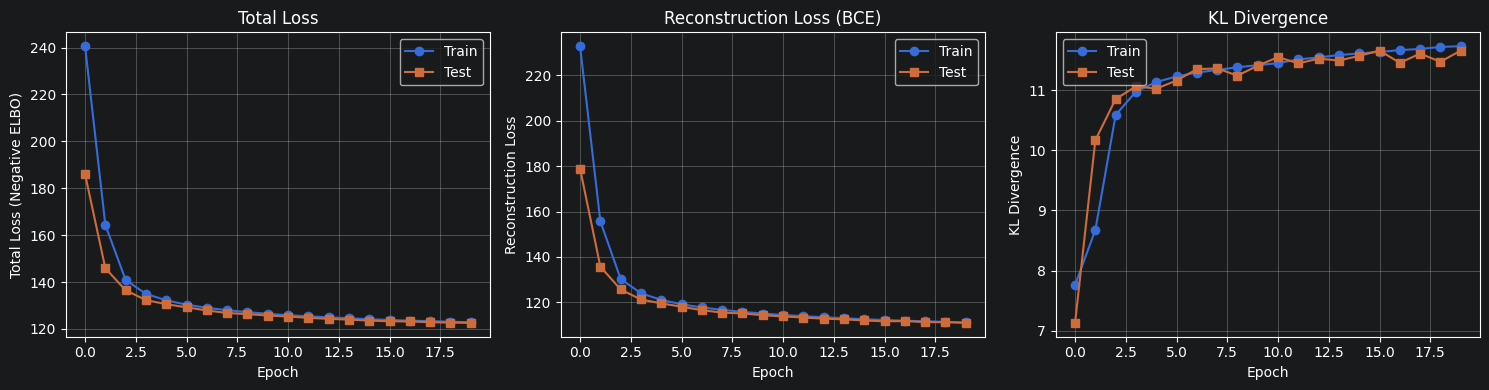

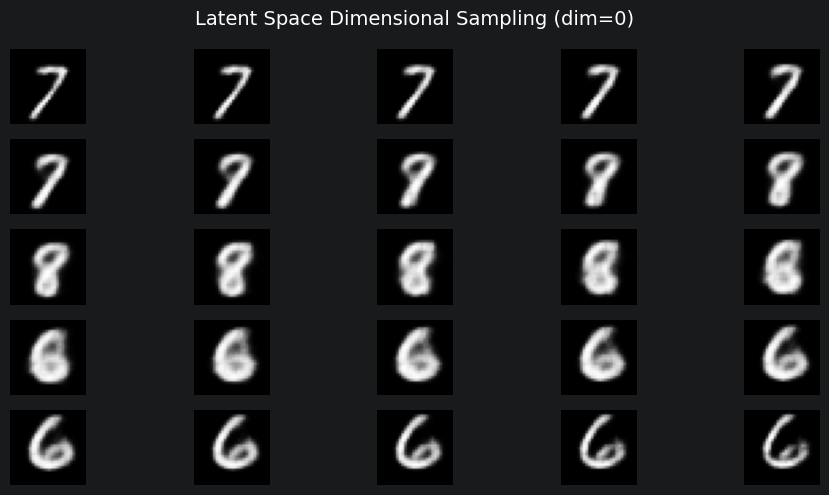

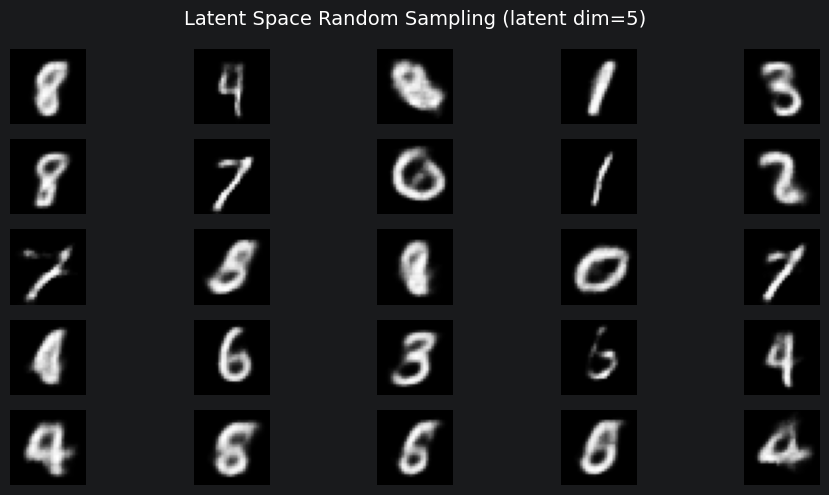

100%|██████████| 39/39 [00:00<00:00, 60.47it/s]


Latent space shape: (9984, 5)
Performing t-SNE dimensionality reduction from 5D to 2D...


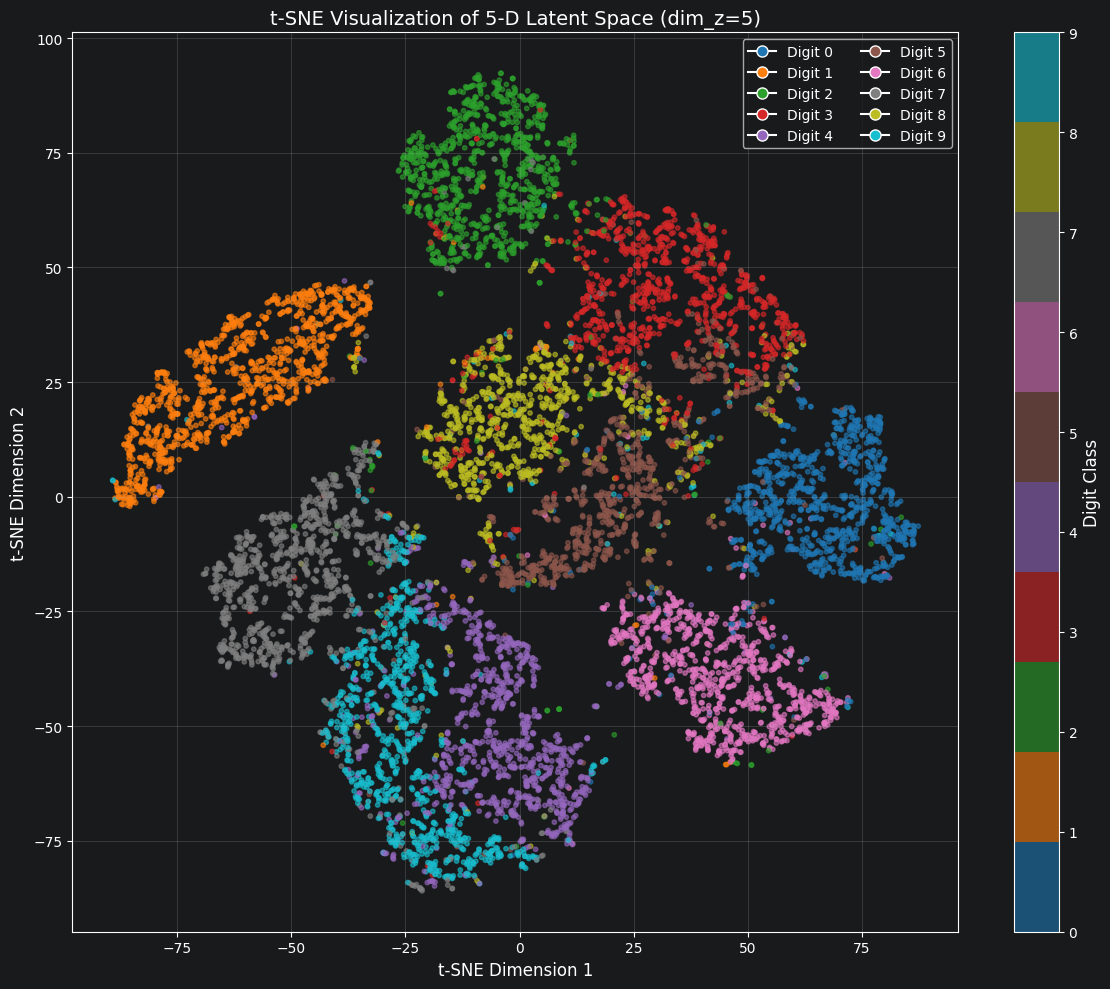

In [9]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Total loss
axes[0].plot(train_losses, label='Train', marker='o')
axes[0].plot(test_losses, label='Test', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss (Negative ELBO)')
axes[0].set_title('Total Loss')
axes[0].legend()
axes[0].grid(True)

# Reconstruction loss
axes[1].plot(train_recon_losses, label='Train', marker='o')
axes[1].plot(test_recon_losses, label='Test', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Reconstruction Loss')
axes[1].set_title('Reconstruction Loss (BCE)')
axes[1].legend()
axes[1].grid(True)

# KL divergence
axes[2].plot(train_kl_losses, label='Train', marker='o')
axes[2].plot(test_kl_losses, label='Test', marker='s')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence')
axes[2].set_title('KL Divergence')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

dimensional_sampling(VAENF, dim=0, start=-3, stop=3, num_steps=25, n_cols=5, noise_mean=0, noise_std=0)
generate_random_samples(VAENF, num_samples=25)
visualize_latent_space(VAENF, test_loader, perplexity=30)

### Evaluation

Conduct the exact same evaluation as you did for the vanilla VAE.
<u>Produce the same kind of plots and answer the same questions **again**!</u>

**Question**: For the second plot: What did any of the latent dimensions learned? What happens when you animate a single dimension between, say, `[-3,3]`?

**Answer**: With the normalizing flow, the image seems to be blurrier on average, and if I try higher K-values I end up with static noise, but with K = 6, we can see almost the same thing we saw in the regular VAE, a gradual transition across digits. A K = 8 gives somewhat clearer images but still quite blurry at the crossovers between digits.

**Question**: What is your qualitative evaluation of the samples from the 3rd plot?

**Answer**: With K = 4 I get almost cryptic representations of 4's and 9's, while K = 6 gives mostly blurry images. K = 8 gives quite clean images except for some that are a bit cryptic and unintelligible at times.

**Question**: What is your interpretation of the 4th plot? Has the model learned something useful?

**Answer**: Looking at the new t-SNE plot, there are still good clusters, just not as clear as the regular VAE. And this time there seems to be a larger amount of intermingling between classes. K = 4 gives better clustering except for 4's and 9's (probably from their similarities), K = 6 has ok clustering (there is some intermingling between nearby clusters) and K = 8 gives another ok rendition with for example 3's and 5's mixing.

**Another Question**: Which model is better? How did you measure this and come to that conclusion?

**Answer**: In the case of K = 6, I can't say. They both have a KL-divergence of ~ 9.75 and -ELBO of ~ 121, so from my perspective I would say that the first (regular VAE) is better for it's simplicity and computational speed compared to the VAE with NF. when K = 8 I would choose the VAEwithNF for its lower loss of ~ 110 and KL divergence of ~ 11.65.